# Heart Failure Diagnosis with MIMIC-III and BioBERT

## Step 1: Import Libraries


In [1]:
!pip install seqeval
!pip install wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - \ | done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16161 sha256=777a841fef73455dd1bb11d89d1f71fd7ba5ca95757a7a01895335d6b7557a30
  Stored in directory: /root/.cache/pip/wheels/1a/67/4a/ad4082dd7dfc30f2abfe4d80a2ed5926a506eb8a972b4767fa
Successfully built seqeval


In [2]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer
from transformers import DataCollatorForTokenClassification
from datasets import Dataset
from sklearn.model_selection import train_test_split
from seqeval.metrics import classification_report as seqeval_classification_report
from seqeval.metrics import accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import wandb

## Step 2: Load the Data
In this step, we load the necessary MIMIC-III tables (NOTEEVENTS, DIAGNOSES_ICD, and ADMISSIONS) into Pandas DataFrames using pd.read_csv() function. The NOTEEVENTS table provides clinical notes, DIAGNOSES_ICD contains diagnostic codes, and ADMISSIONS holds patient admission details. Loading these tables allows us to access the raw data and perform subsequent data preprocessing and analysis steps to identify patients diagnosed with heart failure and extract relevant clinical notes.

In [3]:
# Load NOTEEVENTS
notes = pd.read_csv('/kaggle/input/mimic-iii-10k/MIMIC -III (10000 patients)/NOTEEVENTS/NOTEEVENTS_random.csv')

# Load DIAGNOSES_ICD
diagnoses = pd.read_csv('/kaggle/input/mimic-iii-10k/MIMIC -III (10000 patients)/DIAGNOSES_ICD/DIAGNOSES_ICD_random.csv')

# Load ADMISSIONS
admissions = pd.read_csv('/kaggle/input/mimic-iii-10k/MIMIC -III (10000 patients)/ADMISSIONS/ADMISSIONS_random.csv')

/tmp/ipykernel_23/3642182213.py:2: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  notes = pd.read_csv('/kaggle/input/mimic-iii-10k/MIMIC -III (10000 patients)/NOTEEVENTS/NOTEEVENTS_random.csv')


## Step 3: Data Preprocessing
In this step, we filter the data for heart failure diagnoses by selecting records from the DIAGNOSES_ICD table where the ICD9_CODE matches known heart failure codes such as '4280'. We then merge this subset with the NOTEEVENTS table on SUBJECT_ID and HADM_ID to get the associated clinical notes, focusing on note categories like 'Discharge summary' and 'Nursing/other' that are more likely to contain symptom descriptions.

In [4]:
# Filter diagnoses for heart failure
heart_failure_codes = ['4280', '42800', '4280']  # Variations of ICD-9 code 428.0
hf_diagnoses = diagnoses[diagnoses['ICD9_CODE'].isin(heart_failure_codes)]

# Get unique patient and admission IDs
hf_patients = hf_diagnoses[['SUBJECT_ID', 'HADM_ID']].drop_duplicates()

In [5]:
# Merge heart failure patients with notes
hf_notes = pd.merge(hf_patients, notes, on=['SUBJECT_ID', 'HADM_ID'])

# Filter notes to include only 'Discharge summary' or 'Nursing' notes
hf_notes = hf_notes[hf_notes['CATEGORY'].isin(['Discharge summary', 'Nursing/other'])]

# Reset index
hf_notes = hf_notes.reset_index(drop=True)

In [6]:
# Use a subset of the data for demonstration purposes
hf_notes = hf_notes.sample(n=6000, random_state=42).reset_index(drop=True)

In [7]:
hf_notes

,SUBJECT_ID,HADM_ID,ROW_ID,CHARTDATE,CHARTTIME,STORETIME,CATEGORY,DESCRIPTION,CGID,ISERROR,TEXT
0,433,120589,1266597,2162-02-01,2162-02-01 05:20:00,2162-02-01 05:30:00,Nursing/other,Report,15746.0,NaN,NSG NOTE\n\nCV: REMAINS IN NSR HR 75-93. SBP 9...
1,10446,146958,1400628,2164-03-30,2164-03-30 05:39:00,2164-03-30 06:05:00,Nursing/other,Report,15407.0,NaN,MICU Nurse Progress Note 1900-0700\nEvents: Ab...
2,28029,194661,1628718,2116-11-27,2116-11-27 05:39:00,2116-11-27 05:42:00,Nursing/other,Report,17443.0,NaN,Resp: [**Name (NI) 516**] pt via ER with #8 po...
3,19991,190981,1525338,2162-05-18,2162-05-18 21:50:00,2162-05-18 22:05:00,Nursing/other,Report,18461.0,NaN,1900-2200 EVENT NOTE\nFamily meeting today. Pt...
4,11589,172346,1414005,2194-12-28,2194-12-28 18:38:00,2194-12-28 18:51:00,Nursing/other,Report,16021.0,NaN,pmicu nursing progress note\nresp: present v...
...,...,...,...,...,...,...,...,...,...,...,...
5995,7118,127146,13587,2118-07-07,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2118-6-25**] ...
5996,781,163526,1271347,2117-09-29,2117-09-29 05:25:00,2117-09-29 05:51:00,Nursing/other,Report,17474.0,NaN,Neuro: pt [** **] when awake easily [** **] wh...
5997,30429,191715,59300,2160-01-14,NaN,NaN,Discharge summary,Addendum,NaN,NaN,"Name: [**Known lastname 17250**],[**Known fir..."
5998,5369,114826,1333068,2180-10-12,2180-10-12 06:35:00,2180-10-12 06:41:00,Nursing/other,Report,17053.0,NaN,ccu nsg progress note.\no:neuro=pleasant. coop...


## Step 4: Prepare Data for NER

* `O`: Tokens that are outside of any symptom entity; no correspondence to heart failure symptoms in the clinical text.
* `B-SYMPTOM`: The beginning of a heart failure symptom entity, marking the first token of a symptom mentioned in the clinical notes.
* `I-SYMPTOM`:Tokens that are inside a heart failure symptom entity but are not the first token, continuing the symptom expression in the text.

In [8]:
# List of symptoms related to heart failure
symptom_list = [
    # Shortness of breath
    'shortness of breath', 'dyspnea', 'difficulty breathing', 'breathlessness', 'trouble breathing', 
    'labored breathing', 'short of breath', 'shortness of air', 'unable to catch breath',

    # Fatigue and weakness
    'fatigue', 'weakness', 'tiredness', 'exhaustion', 'lethargy', 'lack of energy', 'feeling tired', 
    'feeling weak', 'exercise intolerance', 'reduced ability to exercise',

    # Swelling (Edema)
    'swelling', 'edema', 'leg swelling', 'ankle swelling', 'feet swelling', 'pedal edema', 
    'peripheral edema', 'fluid retention', 'ascites', 'abdominal swelling', 'bloating',

    # Rapid or irregular heartbeat
    'rapid heartbeat', 'tachycardia', 'palpitations', 'irregular heartbeat', 'arrhythmia', 
    'heart racing', 'skipped beats', 'fluttering in chest',

    # Persistent cough or wheezing
    'persistent cough', 'chronic cough', 'coughing', 'wheezing', 'cough with white or pink blood-tinged mucus', 
    'productive cough', 'frothy sputum', 'pulmonary congestion',

    # Increased urination
    'increased need to urinate at night', 'nocturia', 'frequent urination', 'nighttime urination',

    # Lack of appetite and nausea
    'lack of appetite', 'loss of appetite', 'anorexia', 'nausea', 'feeling sick', 'vomiting', 
    'abdominal discomfort',

    # Cognitive impairment
    'difficulty concentrating', 'confusion', 'memory loss', 'decreased alertness', 'dizziness', 
    'lightheadedness',

    # Chest pain
    'chest pain', 'angina', 'pressure in chest', 'tightness in chest', 'chest discomfort',

    # Other symptoms
    'weight gain', 'rapid weight gain', 'sudden weight gain', 'cold extremities', 'cyanosis', 'bluish skin', 
    'night sweats', 'orthopnea', 'paroxysmal nocturnal dyspnea', 'shortness of breath when lying down', 'sleep apnea',
    'syncope', 'fainting', 'fluid in lungs', 'pulmonary edema', 'jugular venous distension', 'JVD', 'hepatomegaly', 
    'enlarged liver', 'decreased urine output', 'oliguria', 'restlessness', 'anxiety',

    # Common misspellings and abbreviations
    'dysnea', 'dyspnoea', 'SOB',  # Shortness of Breath
    'DOE',  # Dyspnea on Exertion
    'PND',  # Paroxysmal Nocturnal Dyspnea
    'orthopnoea', 'palpitation', 'edem', 'nauseous', 'syncopal episode', 'DOE on exertion',

    # Medical terms
    'pleural effusion', 'effusion', 'hypoxia', 'hypoxemia', 'cyanotic', 'rales', 'crackles', 
    'third heart sound', 'S3 gallop', 'cardiomegaly', 'enlarged heart', 'hepatojugular reflux', 'HJR', 
    'cool extremities', 'diaphoresis', 'sweating', 'tachypnea', 'rapid breathing', 'pulmonary rales', 
    'bilateral crackles',

    # Expressions and phrases
    'unable to lie flat', 'uses multiple pillows', 'sleeping in recliner', 'waking up gasping for air', 
    'pitting edema', 'fluid overload', 'reduced appetite', 'decreased appetite', 'general malaise', 
    'feeling unwell', 'exercise intolerance', 'difficulty performing daily activities', 'decreased activity tolerance', 
    'climbing stairs is difficult', 'walking short distances causes fatigue',

    # Heart failure classifications (might be mentioned)
    'New York Heart Association Class II', 'NYHA Class II', 'NYHA Class III', 'ejection fraction reduced', 
    'reduced ejection fraction', 'HFrEF', 'HFpEF',

    # Other related symptoms
    'coughing up blood', 'hemoptysis', 'sleep disturbances', 'paroxysmal dyspnea', 'weight loss', 'cachexia', 
    'muscle wasting', 'cool skin', 'pale skin', 'tachyarrhythmia', 'ventricular tachycardia', 'atrial fibrillation', 
    'afib', 'fluid weight gain', 'hepatomegaly', 'hepatic congestion', 'splenomegaly', 'swollen abdomen', 'ascitic fluid',
]

In [9]:
def label_severity(text):
    text = text.lower()
    severe = ['nyha class iv', 'unable to lie flat', 'multiple pillows', 'ventilator', 'icu']
    moderate = ['nyha class ii', 'nyha class iii', 'moderate', 'paroxysmal dyspnea']
    symptom_count = sum(symptom in text for symptom in symptom_list)
    if any(k in text for k in severe) or symptom_count > 12:
        return 'severe'
    elif any(k in text for k in moderate) or 6 < symptom_count <= 12:
        return 'moderate'
    else:
        return 'mild'

hf_notes['severity'] = hf_notes['TEXT'].apply(label_severity)
severity_classes = ['mild', 'moderate', 'severe']
severity2id = {v: i for i, v in enumerate(severity_classes)}
hf_notes['severity_label'] = hf_notes['severity'].map(severity2id)

In [10]:
tokenizer = AutoTokenizer.from_pretrained('dmis-lab/biobert-base-cased-v1.1')

def tokenize_and_label(batch):
    texts = [text.lower() for text in batch['TEXT']]
    encodings = tokenizer(
        texts,
        truncation=True,
        padding='max_length',
        max_length=128,  # Reduced max_length
        return_offsets_mapping=True,
    )
    batch_size = len(texts)
    all_labels = []

    for i in range(batch_size):
        text = texts[i]
        offset_mapping = encodings['offset_mapping'][i]
        labels = ['O'] * len(encodings['input_ids'][i])

        symptom_spans = []
        for symptom in symptom_list:
            symptom = symptom.lower()
            start = 0
            while True:
                idx = text.find(symptom, start)
                if idx == -1:
                    break
                symptom_spans.append((idx, idx + len(symptom)))
                start = idx + len(symptom)

        for idx, (start_char, end_char) in enumerate(offset_mapping):
            if start_char == 0 and end_char == 0:
                labels[idx] = -100  # Special tokens
                continue
            token_start = start_char
            token_end = end_char
            token_label = 'O'
            for span_start, span_end in symptom_spans:
                if token_start >= span_start and token_end <= span_end:
                    if token_start == span_start:
                        token_label = 'B-SYMPTOM'
                    else:
                        token_label = 'I-SYMPTOM'
                    break
            labels[idx] = label2id.get(token_label, 'O')
        all_labels.append(labels)

    encodings['labels'] = all_labels
    return encodings


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [11]:
label_list = ['O', 'B-SYMPTOM', 'I-SYMPTOM']
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}

In [12]:
# Create a HuggingFace Dataset
dataset = Dataset.from_pandas(hf_notes[['TEXT']])

# Apply tokenization and labeling with batched processing
tokenized_dataset = dataset.map(tokenize_and_label, batched=True, batch_size=32)

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

## Step 5: Split Data into Train and Test Sets

In [13]:
# Split the dataset
train_test = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = train_test['train']
test_dataset = train_test['test']

## Step 6: Set Up the Data Collator

In [14]:
data_collator = DataCollatorForTokenClassification(tokenizer, padding='longest')

## Step 7: Load BioBERT Model

In [15]:
model = AutoModelForTokenClassification.from_pretrained(
    'dmis-lab/biobert-base-cased-v1.1',
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Step 8: Define Evaluation Metrics

In [16]:
from seqeval.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score
from itertools import chain

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_labels = [[label_list[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [label_list[pred] for (pred, lab) in zip(prediction, label) if lab != -100]
        for prediction, label in zip(predictions, labels)
    ]

    # Flatten the lists
    flat_labels = list(chain.from_iterable(true_labels))
    flat_predictions = list(chain.from_iterable(true_predictions))

    print("Classification Report:\n")
    print(classification_report(flat_labels, flat_predictions, digits=4))

    return {
        "precision": precision_score(flat_labels, flat_predictions, average="weighted"),
        "recall": recall_score(flat_labels, flat_predictions, average="weighted"),
        "f1": f1_score(flat_labels, flat_predictions, average="weighted"),
        "accuracy": accuracy_score(flat_labels, flat_predictions),
    }

In [17]:
from datasets import DatasetDict
from transformers import AutoModelForSequenceClassification

def tokenize_severity(batch):
    return tokenizer(batch['TEXT'], truncation=True, padding=True, max_length=256)

severity_dataset = Dataset.from_pandas(hf_notes[['TEXT', 'severity_label']])
severity_dataset = DatasetDict(severity_dataset.train_test_split(test_size=0.2, seed=42))
severity_dataset = severity_dataset.rename_column("severity_label", "labels")
severity_tokenized = severity_dataset.map(tokenize_severity, batched=True)

severity_model = AutoModelForSequenceClassification.from_pretrained(
    'dmis-lab/biobert-base-cased-v1.1',
    num_labels=3,
    id2label={i: l for i, l in enumerate(severity_classes)},
    label2id=severity2id,
)

from sklearn.metrics import accuracy_score, f1_score as sk_f1_score

def severity_metrics(p):
    logits = p.predictions
    labels = p.label_ids
    preds = np.argmax(logits, axis=1)

    # Compute loss manually
    loss_fn = torch.nn.CrossEntropyLoss()
    logits_tensor = torch.tensor(logits, dtype=torch.float32)
    labels_tensor = torch.tensor(labels, dtype=torch.long)
    loss = loss_fn(logits_tensor, labels_tensor)

    return {
        "loss": loss.item(),
        "accuracy": accuracy_score(labels, preds),
        "f1": sk_f1_score(labels, preds, average="weighted"),
    }

Map:   0%|          | 0/4800 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Step 9: Set Up Training Arguments , Trainer Initialization and Training

In [18]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=wandb_api_key)
wandb.init(project='Symptom-Extraction', name='BioBERT-Symptom-Extraction')

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gayathrisnambiar8 (gayathrisnambiar8-rv-college-of-engineering). Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.18.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250626_084628-1znqgunr
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run BioBERT-Symptom-Extraction
wandb: ⭐️ View project at https://wandb.ai/gayathrisnambiar8-rv-college-of-engineering/Symptom-Extraction
wandb: 🚀 View run at https://wandb.ai/gayathris

In [19]:
import wandb

def safe_init_wandb(project, run_name, config_dict):
    if wandb.run is not None:
        wandb.finish()
    wandb.init(project=project, name=run_name, reinit=True)
    for k, v in config_dict.items():
        wandb.config.update({k: v}, allow_val_change=True)

In [20]:
safe_init_wandb(
    project="Severity-Classification",
    run_name="HF-Severity-Classifier",
    config_dict={"model/num_parameters": 108312579}
)

severity_trainer = Trainer(
    model=severity_model,
    args=TrainingArguments(
        output_dir='/kaggle/working/severity_classifier',
        eval_strategy='epoch',
        save_strategy='epoch',
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=4,
        report_to='wandb',
        run_name='HF-Severity-Classifier',
        save_safetensors=False,
        fp16=True,
    ),
    train_dataset=severity_tokenized['train'],
    eval_dataset=severity_tokenized['test'],
    tokenizer=tokenizer,
    compute_metrics=severity_metrics,
)

severity_trainer.train()
severity_trainer.save_model('/kaggle/working/severity_classifier')
wandb.finish()

wandb:                                                                                
wandb: 🚀 View run BioBERT-Symptom-Extraction at: https://wandb.ai/gayathrisnambiar8-rv-college-of-engineering/Symptom-Extraction/runs/1znqgunr
wandb: ⭐️ View project at: https://wandb.ai/gayathrisnambiar8-rv-college-of-engineering/Symptom-Extraction
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20250626_084628-1znqgunr/logs
wandb: Tracking run with wandb version 0.18.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250626_084631-s429gav7
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run HF-Severity-Classifier
wandb: ⭐️ View project at https://wandb.ai/gayathrisnambiar8-rv-college-of-engineering/Severity-Classification
wandb: 🚀 View run at https://wandb.ai/gayathrisnambiar8-rv-college-of-engineering/Severity-Classification/runs/s429gav7
/opt/conda/lib/python3.10/site-packages/accelerate/accelerato

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.297580,0.911667,0.896231
2,0.413100,0.194918,0.944167,0.943847
3,0.413100,0.247201,0.922500,0.922500
4,0.175300,0.315846,0.931667,0.931516


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁█▃▅
wandb:                 eval/f1 ▁█▅▆
wandb:               eval/loss ▇▁▄█
wandb:            eval/runtime ▇▁▃█
wandb: eval/samples_per_second ▂█▆▁
wandb:   eval/steps_per_second ▂█▆▁
wandb:             train/epoch ▁▃▃▆▆██
wandb:       train/global_step ▁▃▃▆▆██
wandb:         train/grad_norm ▁█
wandb:     train/learning_rate █▁
wandb:              train/loss █▁
wandb: 
wandb: Run summary:
wandb:            eval/accuracy 0.93167
wandb:                  eval/f1 0.93152
wandb:                eval/loss 0.31585
wandb:             eval/runtime 8.9205
wandb:  eval/samples_per_second 134.522
wandb:    eval/steps_per_second 8.408
wandb:               total_flos 2525888810188800.0
wandb:              train/epoch 4
wandb:        train/global_step 1200
wandb:          train/grad_norm 4.23192
wandb:      train/learning_rate 1e-05
wandb:               tra

In [21]:
safe_init_wandb(
    project="Symptom-Extraction",
    run_name="BioBERT-Symptom-Extraction",
    config_dict={"model/num_parameters": 107721987}
)

training_args = TrainingArguments(
    output_dir='/kaggle/working/',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    evaluation_strategy='epoch',
    logging_strategy='steps',
    logging_steps=100,
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to='wandb',
    run_name='BioBERT-Symptom-Extraction',
    save_safetensors=False,
    gradient_checkpointing=True,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

wandb: Tracking run with wandb version 0.18.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250626_085500-54cl9gbj
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run BioBERT-Symptom-Extraction
wandb: ⭐️ View project at https://wandb.ai/gayathrisnambiar8-rv-college-of-engineering/Symptom-Extraction
wandb: 🚀 View run at https://wandb.ai/gayathrisnambiar8-rv-college-of-engineering/Symptom-Extraction/runs/54cl9gbj
/opt/conda/lib/python3.10/site-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [22]:
import transformers
transformers.logging.set_verbosity_info()

In [23]:
trainer.train()

The following columns in the training set don't have a corresponding argument in `BertForTokenClassification.forward` and have been ignored: TEXT, offset_mapping. If TEXT, offset_mapping are not expected by `BertForTokenClassification.forward`,  you can safely ignore this message.
***** Running training *****
  Num examples = 4,800
  Num Epochs = 5
  Instantaneous batch size per device = 16
  Total train batch size (w. parallel, distributed & accumulation) = 16
  Gradient Accumulation steps = 1
  Total optimization steps = 1,500
  Number of trainable parameters = 107,721,987
Automatic Weights & Biases logging enabled, to disable set os.environ["WANDB_DISABLED"] = "true"
/opt/conda/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:600: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current defa

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.003800,0.003264,0.999211,0.999192,0.999199,0.999192
2,0.001200,0.001882,0.999559,0.999562,0.999559,0.999562
3,0.000700,0.001586,0.999527,0.999523,0.999525,0.999523
4,0.000500,0.001661,0.999639,0.999639,0.999639,0.999639
5,0.000300,0.001865,0.999573,0.999569,0.999571,0.999569


The following columns in the evaluation set don't have a corresponding argument in `BertForTokenClassification.forward` and have been ignored: TEXT, offset_mapping. If TEXT, offset_mapping are not expected by `BertForTokenClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 1200
  Batch size = 16


Classification Report:

              precision    recall  f1-score   support

   B-SYMPTOM     0.9512    0.9640    0.9576       445
   I-SYMPTOM     0.9202    0.9644    0.9418       562
           O     0.9997    0.9995    0.9996    129011

    accuracy                         0.9992    130018
   macro avg     0.9570    0.9760    0.9663    130018
weighted avg     0.9992    0.9992    0.9992    130018



Saving model checkpoint to /kaggle/working/checkpoint-300
Configuration saved in /kaggle/working/checkpoint-300/config.json
Model weights saved in /kaggle/working/checkpoint-300/pytorch_model.bin
tokenizer config file saved in /kaggle/working/checkpoint-300/tokenizer_config.json
Special tokens file saved in /kaggle/working/checkpoint-300/special_tokens_map.json
/opt/conda/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:600: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/torch/utils/checkpoint.py:295: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autoca

...

Classification Report:

              precision    recall  f1-score   support

   B-SYMPTOM     0.9797    0.9775    0.9786       445
   I-SYMPTOM     0.9717    0.9786    0.9752       562
           O     0.9998    0.9998    0.9998    129011

    accuracy                         0.9996    130018
   macro avg     0.9838    0.9853    0.9845    130018
weighted avg     0.9996    0.9996    0.9996    130018



Saving model checkpoint to /kaggle/working/checkpoint-1200
Configuration saved in /kaggle/working/checkpoint-1200/config.json
Model weights saved in /kaggle/working/checkpoint-1200/pytorch_model.bin
tokenizer config file saved in /kaggle/working/checkpoint-1200/tokenizer_config.json
Special tokens file saved in /kaggle/working/checkpoint-1200/special_tokens_map.json
/opt/conda/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:600: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/torch/utils/checkpoint.py:295: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.a

Classification Report:

              precision    recall  f1-score   support

   B-SYMPTOM     0.9732    0.9775    0.9753       445
   I-SYMPTOM     0.9599    0.9804    0.9701       562
           O     0.9998    0.9997    0.9998    129011

    accuracy                         0.9996    130018
   macro avg     0.9776    0.9859    0.9817    130018
weighted avg     0.9996    0.9996    0.9996    130018



Saving model checkpoint to /kaggle/working/checkpoint-1500
Configuration saved in /kaggle/working/checkpoint-1500/config.json
Model weights saved in /kaggle/working/checkpoint-1500/pytorch_model.bin
tokenizer config file saved in /kaggle/working/checkpoint-1500/tokenizer_config.json
Special tokens file saved in /kaggle/working/checkpoint-1500/special_tokens_map.json


Training completed. Do not forget to share your model on huggingface.co/models =)


Loading best model from /kaggle/working/checkpoint-1200 (score: 0.999638809134044).


TrainOutput(global_step=1500, training_loss=0.006668153839185834, metrics={'train_runtime': 436.2803, 'train_samples_per_second': 55.011, 'train_steps_per_second': 3.438, 'total_flos': 1567794714624000.0, 'train_loss': 0.006668153839185834, 'epoch': 5.0})

In [24]:
# Save the trained model
trainer.save_model('/kaggle/working/')

Saving model checkpoint to /kaggle/working/
Configuration saved in /kaggle/working/config.json
Model weights saved in /kaggle/working/pytorch_model.bin
tokenizer config file saved in /kaggle/working/tokenizer_config.json
Special tokens file saved in /kaggle/working/special_tokens_map.json


## Step 10: Evaluate the Model

In [25]:
# Evaluate the model
results = trainer.evaluate()
print("Evaluation Results:")
print(results)

The following columns in the evaluation set don't have a corresponding argument in `BertForTokenClassification.forward` and have been ignored: TEXT, offset_mapping. If TEXT, offset_mapping are not expected by `BertForTokenClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 1200
  Batch size = 16


Classification Report:

              precision    recall  f1-score   support

   B-SYMPTOM     0.9797    0.9775    0.9786       445
   I-SYMPTOM     0.9717    0.9786    0.9752       562
           O     0.9998    0.9998    0.9998    129011

    accuracy                         0.9996    130018
   macro avg     0.9838    0.9853    0.9845    130018
weighted avg     0.9996    0.9996    0.9996    130018

Evaluation Results:
{'eval_loss': 0.001660661306232214, 'eval_precision': 0.9996392214334823, 'eval_recall': 0.9996385115907028, 'eval_f1': 0.999638809134044, 'eval_accuracy': 0.9996385115907028, 'eval_runtime': 7.5585, 'eval_samples_per_second': 158.762, 'eval_steps_per_second': 9.923, 'epoch': 5.0}


## Step 11: Visualize the Confusion Matrix
In this step, we obtain the model’s predictions on the test dataset and extract the true labels and predicted labels for each token. We then use the confusion_matrix function from sklearn.metrics to calculate the confusion matrix, which shows the number of correct and incorrect predictions for each class. Finally, we visualize the confusion matrix using ConfusionMatrixDisplay, providing a graphical representation of the model’s classification performance and highlighting where the model may be confusing different classes.

The following columns in the test set don't have a corresponding argument in `BertForTokenClassification.forward` and have been ignored: TEXT, offset_mapping. If TEXT, offset_mapping are not expected by `BertForTokenClassification.forward`,  you can safely ignore this message.

***** Running Prediction *****
  Num examples = 1200
  Batch size = 16


Classification Report:

              precision    recall  f1-score   support

   B-SYMPTOM     0.9797    0.9775    0.9786       445
   I-SYMPTOM     0.9717    0.9786    0.9752       562
           O     0.9998    0.9998    0.9998    129011

    accuracy                         0.9996    130018
   macro avg     0.9838    0.9853    0.9845    130018
weighted avg     0.9996    0.9996    0.9996    130018



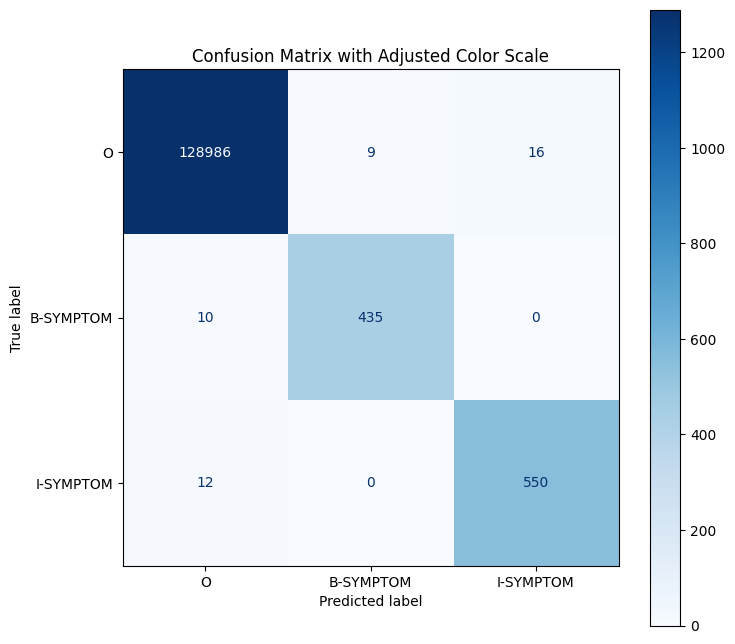

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
predictions, labels, _ = trainer.predict(test_dataset)
predictions = np.argmax(predictions, axis=2)

true_labels = []
true_predictions = []

for i, label in enumerate(labels):
    temp_true_labels = []
    temp_true_preds = []
    for j, l in enumerate(label):
        if l != -100:
            temp_true_labels.append(id2label[l])
            temp_true_preds.append(id2label[predictions[i][j]])
    true_labels.extend(temp_true_labels)
    true_predictions.extend(temp_true_preds)

# Define label order for confusion matrix
label_order = ['O', 'B-SYMPTOM', 'I-SYMPTOM']

# Compute confusion matrix
cm = confusion_matrix(true_labels, true_predictions, labels=label_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap='Blues', ax=ax)

# Set a custom maximum value to cap the color intensity
max_value = cm.max()
disp.im_.set_clim(0, max_value * 0.01)  # Adjust the denominator to control the cap

plt.title('Confusion Matrix with Adjusted Color Scale')
plt.show()

The following columns in the test set don't have a corresponding argument in `BertForSequenceClassification.forward` and have been ignored: TEXT. If TEXT are not expected by `BertForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Prediction *****
  Num examples = 1200
  Batch size = 16


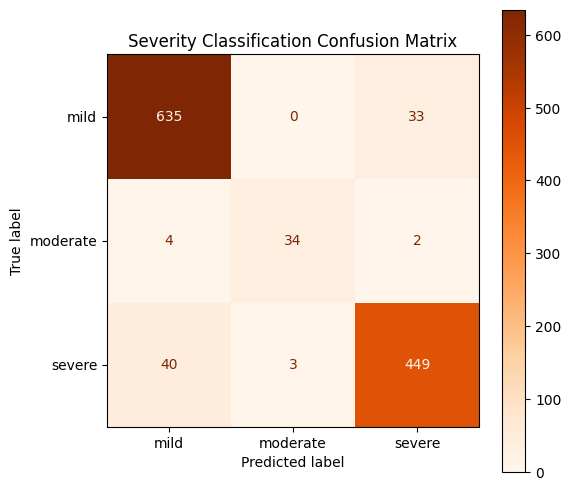

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

preds_output = severity_trainer.predict(severity_tokenized['test'])
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=severity_classes)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Oranges', ax=ax)
plt.title("Severity Classification Confusion Matrix")
plt.show()

## Step 12: Print Classification Report
In this step, we generate a detailed classification report using the classification_report function from sklearn.metrics. The report shows precision, recall, F1-score, and support for each class label ('O', 'B-SYMPTOM', 'I-SYMPTOM'), offering a comprehensive overview of the model’s performance on each label. Printing this report helps us understand which labels are being correctly identified and which may require further attention, providing a final summary of the model’s ability to perform symptom extraction from clinical notes.

In [28]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(true_labels, true_predictions, labels=label_order))

Classification Report:
              precision    recall  f1-score   support

           O       1.00      1.00      1.00    129011
   B-SYMPTOM       0.98      0.98      0.98       445
   I-SYMPTOM       0.97      0.98      0.98       562

    accuracy                           1.00    130018
   macro avg       0.98      0.99      0.98    130018
weighted avg       1.00      1.00      1.00    130018



In [29]:
predictions_output = severity_trainer.predict(severity_tokenized['test'])

preds = np.argmax(predictions_output.predictions, axis=1)

labels = predictions_output.label_ids
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(labels, preds, digits=4))


The following columns in the test set don't have a corresponding argument in `BertForSequenceClassification.forward` and have been ignored: TEXT. If TEXT are not expected by `BertForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Prediction *****
  Num examples = 1200
  Batch size = 16


Classification Report:

              precision    recall  f1-score   support

           0     0.9352    0.9506    0.9428       668
           1     0.9189    0.8500    0.8831        40
           2     0.9277    0.9126    0.9201       492

    accuracy                         0.9317      1200
   macro avg     0.9273    0.9044    0.9153      1200
weighted avg     0.9316    0.9317    0.9315      1200



## Step 13: Create and Load pkl file

In [30]:
import pickle

# Save model
with open('/kaggle/working/heartfailure_model.pkl', 'wb') as f:
    pickle.dump(trainer.model, f)

# Save tokenizer 
with open('/kaggle/working/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save severity model
with open('/kaggle/working/severity_model.pkl', 'wb') as f:
    pickle.dump(severity_trainer.model, f)
    
print("Saved model and tokenizer to /kaggle/working/")


Saved model and tokenizer to /kaggle/working/


In [31]:
!ls /kaggle/working/*.pkl

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


/kaggle/working/heartfailure_model.pkl	/kaggle/working/tokenizer.pkl
/kaggle/working/severity_model.pkl


In [32]:
with open('/kaggle/working/heartfailure_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('/kaggle/working/severity_model.pkl', 'rb') as f:
    model = pickle.load(f)
    
print("Loaded model:", type(model))

/opt/conda/lib/python3.10/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


Loaded model: <class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'>


In [33]:
from IPython.display import FileLink
FileLink('/kaggle/working/heartfailure_model.pkl')
FileLink('/kaggle/working/severity_model.pkl')

/kaggle/working/severity_model.pkl

In [34]:
# On GPU machine
import torch

# Save the BioBERT symptom extraction model
trainer.model.cpu()  # Move model to CPU before saving
torch.save(trainer.model, '/kaggle/working/heartfailure_model.pt')

# Save the severity classification model
severity_trainer.model.cpu()
torch.save(severity_trainer.model, '/kaggle/working/severity_model.pt')

# Save the tokenizer using Hugging Face's save_pretrained method
tokenizer.save_pretrained('/kaggle/working/tokenizer/')

print("✅ Models and tokenizer saved in torch format to /kaggle/working/")


tokenizer config file saved in /kaggle/working/tokenizer/tokenizer_config.json
Special tokens file saved in /kaggle/working/tokenizer/special_tokens_map.json


✅ Models and tokenizer saved in torch format to /kaggle/working/
